# Paper Name: Rice Leaf Disease Classification using Resource-Efficient Deep Learning Models via Response-Based Knowledge Distillation

Author Name: Maimunul Karim Jisan (https://github.com/maimunul)<br>
University ID: 201001312<br>
Department: CSE<br>
East Delta University<br>
Chittagong, Bangladesh

## Introduction to Rice Leaf Disease Classification using Knowledge Distillation
The main purpose for this project refers to a set of techniques and methodologies aimed at reducing the size of deep learning models, making them more lightweight and efficient while preserving their predictive performance. This is particularly important for deploying models on resource-constrained environments such as mobile devices, edge devices, or IOT devices.There are several technique available but we choose **Reponse-based Knowledge Distillation Technique** to reduce large model size.<br>

**Knowledge Distillation:** Training a smaller "student" model to mimic the behavior of a larger "teacher" model. The smaller model tries to reproduce the predictions and uncertainty estimates of the larger model.<br><br>

To evacute **Response-based Knowledge Distillation** using **Rice Leaf Disease Dataset** from Mendeley Data. Here dataset contain 5932 images with four different rice leaf disease. For example,

Bacterialblight Disease<br>
Blast Disease<br>
Brownspot Disease<br>
Tungro Disease<br>
The dataset contain Train (4745), Test (595) & Validation (592) Images

**Teacher** Model Accuracy is almost 99% on Test Images<br>
Getting **Studen**t model accuracy is 77% on Test Images<br>

## Introduction to Response-based Knowledge Distillation

**Response-based Knowledge Distillation (KD)** transfers knowledge from a large teacher model to a smaller student model by training the student to mimic the teacher’s **soft predictions** (probabilities). The process uses a combination of true labels and the teacher’s probabilistic outputs to improve the student’s generalization. It enhances model efficiency while maintaining performance, making it ideal for deployment on resource-constrained devices.

**Reference:**

- [Hinton et al. (2015)](https://arxiv.org/abs/1503.02531)

## This Notebook maintain Distillation Network: CNN based  Teacher to CNN based student

# Setup

In [1]:
import random
import numpy as np
import tensorflow as tf
import time
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tabulate import tabulate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
import json

c:\Users\My Pc\Desktop\Jisan\journal\review reponse applied soft computing\Review Progress file\R1C8\Rice-Leaf-Disease-Classification-using-Response-Based-Knowledge-Distillation\tf215_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Data Acquisation and Augmentation

In [2]:
# ============================
# Configuration
# ============================
Input_Image = 256
Channels = 3
batch_size = 32
epochs = 30

# ============================
# Generate random seeds from system time
# ============================
# Use current nanoseconds to generate 5 random seeds
base_seed = int(time.time_ns() % 100000)
print(f"Base seed from system time: {base_seed}")

random.seed(base_seed)
seeds = [random.randint(1000, 9999) for _ in range(5)]
print(f"Randomly selected seeds: {seeds}")
print(f"{'='*60}\n")

# ============================
# Data Generators
# ============================
# Data augmentation for training set
train_data = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    shear_range=0.2,
    zoom_range=0.2,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# Validation and test sets
common_data = ImageDataGenerator(rescale=1./255)

# Test set (will be the same for all runs)
test_set = common_data.flow_from_directory(
    r"test",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # No shuffle for consistent evaluation
)

# Validation set (will be the same for all runs)
val_set = common_data.flow_from_directory(
    r"val",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Input shape
input_shape = (Input_Image, Input_Image, Channels)


Base seed from system time: 35800
Randomly selected seeds: [4322, 1475, 1224, 5294, 4396]

Found 595 images belonging to 4 classes.
Found 592 images belonging to 4 classes.


<a ></a>
# <p style="background-color:skyblue; font-family:newtimeroman; font-size:150%; text-align:center; border-radius: 15px 50px;"> Knowledge Distillation 💎</p>


# Loading Teacher Model




19/19 [==============================] - 2s 84ms/step - loss: 0.0710 - accuracy: 0.9916
Model: "teacher"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 127, 127, 16)      0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 125, 125, 32)      4640      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 62, 62, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 60, 60, 64)        18496     
                                  

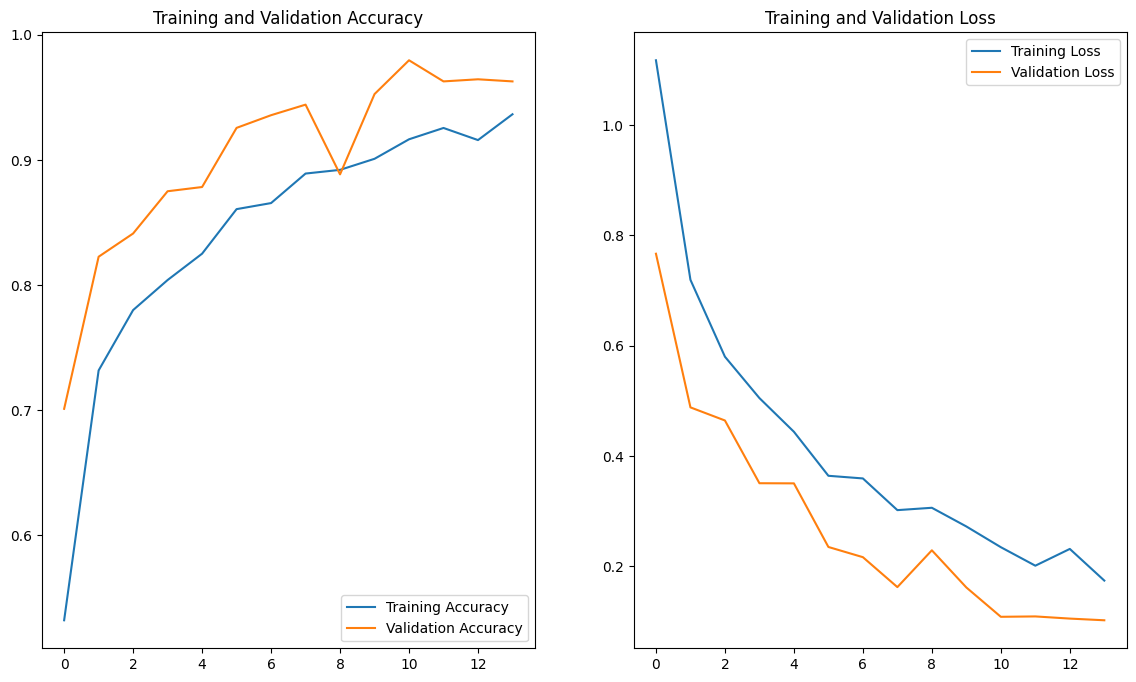

In [3]:
import json
import tensorflow as tf
import matplotlib.pyplot as plt

# Load the model
teacher = tf.keras.models.load_model(r"AlphaSelection\BestTeacher.h5")

# Evaluate and summarize the model
teacher.evaluate(test_set)
teacher.summary()

# Load the training history (JSON format)
history_path = r'Teacher_To_Student\Best_Teacher_history.json'  # JSON file path
with open(history_path, 'r') as history_file:
    loaded_history = json.load(history_file)

# Access metrics from the loaded history
acc = loaded_history['accuracy']
val_acc = loaded_history['val_accuracy']
loss = loaded_history['loss']
val_loss = loaded_history['val_loss']

# Plot the training history
epochs = len(acc)
plt.figure(figsize=(14, 8))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()


# Loading Student Model


19/19 [==============================] - 1s 61ms/step - loss: 0.5833 - accuracy: 0.7782
Model: "student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 127, 127, 16)      0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 125, 125, 16)      2320      
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 62, 62, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 60, 60, 16)        2320      
                                    

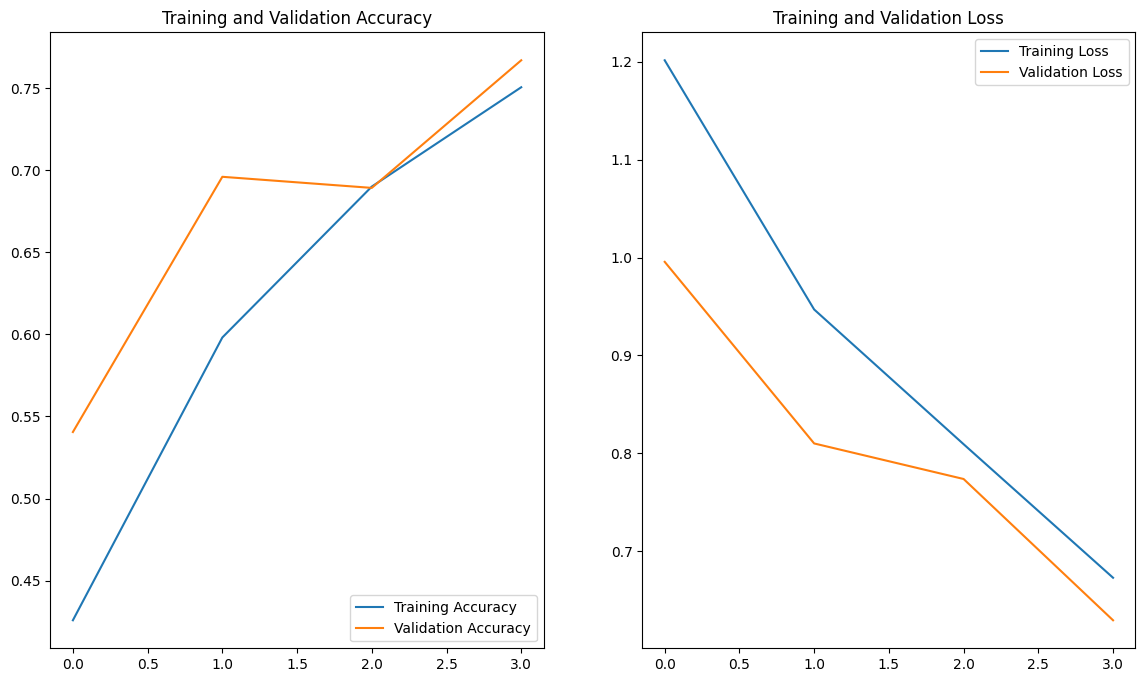

In [4]:
student = tf.keras.models.load_model(r'Teacher_To_Student\NewStudentAccuracy.h5')
# Clone student for later comparison
student_scratch = tf.keras.models.clone_model(student)
# Train student as done usually using data generator
student_scratch.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
student.evaluate(test_set)
student.summary()

import json

history_path = r'Teacher_To_Student\76_Student_history.json'
# Load the saved history
with open(history_path, 'r') as history_file:
    loaded_history = json.load(history_file)

# Access the metrics from the loaded history
print("Training Loss:", loaded_history['loss'])
print("Validation Loss:", loaded_history['val_loss'])
# Similarly, access other metrics like accuracy, etc.
print("Training Accuracy:", loaded_history['accuracy'])
print("Validation Accuracy:", loaded_history['val_accuracy'])


acc = loaded_history['accuracy']
val_acc = loaded_history['val_accuracy']

loss = loaded_history['loss']
val_loss = loaded_history['val_loss']


# Access the metrics from the loaded history
training_loss = loaded_history['loss']
validation_loss = loaded_history['val_loss']

epochs = len(acc)
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()



In [5]:
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=10):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature
        self.mse_metric = tf.keras.metrics.MeanSquaredError(name='mse')
        self.rmse_metric = tf.keras.metrics.RootMeanSquaredError(name='rmse')

    def call(self, inputs, training=False):
        teacher_predictions = self.teacher(inputs, training=False)
        student_predictions = self.student(inputs, training=training)
        return student_predictions

    def train_step(self, data):
        x, y = data
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1)
            ) * self.temperature**2
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        self.compiled_metrics.update_state(y, student_predictions)
        self.mse_metric.update_state(y, student_predictions)
        self.rmse_metric.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"loss": loss, "student_loss": student_loss, 
                        "distillation_loss": distillation_loss, 
                        "mse": self.mse_metric.result(), 
                        "rmse": self.rmse_metric.result()})
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)
        self.mse_metric.update_state(y, y_prediction)
        self.rmse_metric.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss, 
                        "mse": self.mse_metric.result(), 
                        "rmse": self.rmse_metric.result()})
        return results


# Now Finally, Distillation

In [6]:
# ============================
# Callback
# ============================
callbacks = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0,
    patience=3,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

# ============================
# Run Experiments with Different Random Seeds
# ============================
accuracy_results = []
loss_results = []
all_histories = []

print(f"{'='*80}")
print("STABILITY ANALYSIS - Temperature T=10")
print(f"Running experiments with 5 different random seeds")
print(f"{'='*80}\n")

for i, seed in enumerate(seeds):
    print(f"\n{'='*60}")
    print(f"EXPERIMENT {i+1}/5 - Seed: {seed}")
    print(f"{'='*60}")
    
    # ============================
    # Set Random Seeds for Reproducibility
    # ============================
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # ============================
    # Create Fresh Training Set with Current Seed
    # ============================
    train_set = train_data.flow_from_directory(
        r"train",
        target_size=(Input_Image, Input_Image),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True,
        seed=seed  # Different shuffle for each experiment
    )
    
    
    
    
    # ============================
    # Initialize and Compile Distiller
    # ============================
    distiller = Distiller(student=student_scratch, teacher=teacher)
    distiller.compile(
        optimizer='adam',
        metrics=['accuracy'],
        student_loss_fn=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
        distillation_loss_fn=tf.keras.losses.KLDivergence(),
        alpha=0.1,
        temperature=10  # Fixed temperature as per best result
    )
    
    # ============================
    # Train Distiller
    # ============================
    print(f"Training with seed {seed}...")
    history = distiller.fit(
        train_set,
        epochs=epochs,
        validation_data=val_set,
        callbacks=[callbacks]
    )
    
    # ============================
    # Evaluate on Test Set
    # ============================
    print(f"Evaluating on test set...")
        # First, let's manually calculate accuracy to be sure
    test_set.reset()  # Reset test set to beginning
    y_true = []
    y_pred = []
    
    for batch in range(len(test_set)):
        x_batch, y_batch = test_set.next()
        predictions = distiller.student.predict(x_batch, verbose=0)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))
    
    # Calculate accuracy
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    total = len(y_true)
    test_accuracy = (correct / total) * 100
    
    # Also get evaluation using model.evaluate for loss
    test_set.reset()
    eval_results = distiller.evaluate(test_set, verbose=0)
    
    # Extract metrics - The order might vary, so let's find the correct index
    # The metrics are: loss, student_loss, distillation_loss, accuracy, mse, rmse
    # But we already calculated accuracy manually above
    
    # We can also get the accuracy from eval_results by checking the name
    # Let's use the manual calculation for accuracy and get loss from eval_results
    
    # Find loss in eval_results (it should be at index 0 or we can use student_loss)
    # Based on your output, student_loss seems to be at index 2 (0: loss, 1: accuracy, 2: student_loss)
    # But let's be safe and calculate loss from our predictions
    
    # Calculate loss manually
    test_set.reset()
    total_loss = 0
    total_batches = 0
    
    for batch in range(len(test_set)):
        x_batch, y_batch = test_set.next()
        predictions = distiller.student.predict(x_batch, verbose=0)
        batch_loss = tf.keras.losses.categorical_crossentropy(y_batch, predictions)
        total_loss += np.mean(batch_loss)
        total_batches += 1
    
    test_loss = total_loss / total_batches if total_batches > 0 else 0
    
    accuracy_results.append(test_accuracy)
    loss_results.append(test_loss)
    all_histories.append(history.history)
    
    print(f"\nSeed {seed} Results:")
    print(f"  Test Accuracy: {test_accuracy:.2f}%")
    print(f"  Test Loss: {test_loss:.4f}")
    if history.history and 'accuracy' in history.history:
        print(f"  Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    if history.history and 'val_accuracy' in history.history:
        print(f"  Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

STABILITY ANALYSIS - Temperature T=10
Running experiments with 5 different random seeds


EXPERIMENT 1/5 - Seed: 4322
Found 4745 images belonging to 4 classes.
Training with seed 4322...
Epoch 1/4

149/149 [==============================] - 58s 385ms/step - accuracy: 0.4137 - mse: 0.1648 - rmse: 0.4060 - loss: 0.1879 - student_loss: 1.2222 - distillation_loss: 0.0730 - val_accuracy: 0.5878 - val_mse: 0.1324 - val_rmse: 0.3639 - val_student_loss: 1.0725
Epoch 2/4
149/149 [==============================] - 59s 398ms/step - accuracy: 0.6388 - mse: 0.1197 - rmse: 0.3460 - loss: 0.1336 - student_loss: 0.8890 - distillation_loss: 0.0496 - val_accuracy: 0.6030 - val_mse: 0.1301 - val_rmse: 0.3607 - val_student_loss: 1.2630
Epoch 3/4
149/149 [==============================] - 58s 392ms/step - accuracy: 0.7012 - mse: 0.1027 - rmse: 0.3204 - loss: 0.1112 - student_loss: 0.7442 - distillation_loss: 0.0409 - val_accuracy: 0.7500 - val_mse: 0.0855 - val_rmse: 0.2925 - val_student_loss: 0.4308
Epoch

Base seed from system time: 69700
Randomly selected seeds: [8440, 9289, 3005, 8899, 2226]

Loading test set...
Found 595 images belonging to 4 classes.
Loading validation set...
Found 592 images belonging to 4 classes.

Loading teacher model...
Evaluating teacher model on test set...
Teacher Test Accuracy: 99.16%
Teacher Test Loss: 0.0710

Loading student model architecture...
Evaluating original student model on test set...
Original Student Test Accuracy: 77.82%
Original Student Test Loss: 0.5833

STABILITY ANALYSIS - Temperature T=10
Running experiments with 5 different random seeds


EXPERIMENT 1/5 - Seed: 8440
Creating fresh training set...
Found 4745 images belonging to 4 classes.
Creating fresh student model...
Initializing distiller...
Training with seed 8440...
Epoch 1/30
149/149 [==============================] - 58s 382ms/step - accuracy: 0.4542 - mse: 0.1573 - rmse: 0.3966 - loss: 0.1786 - student_loss: 1.1622 - distillation_loss: 0.0694 - val_accuracy: 0.6081 - val_mse: 0.1

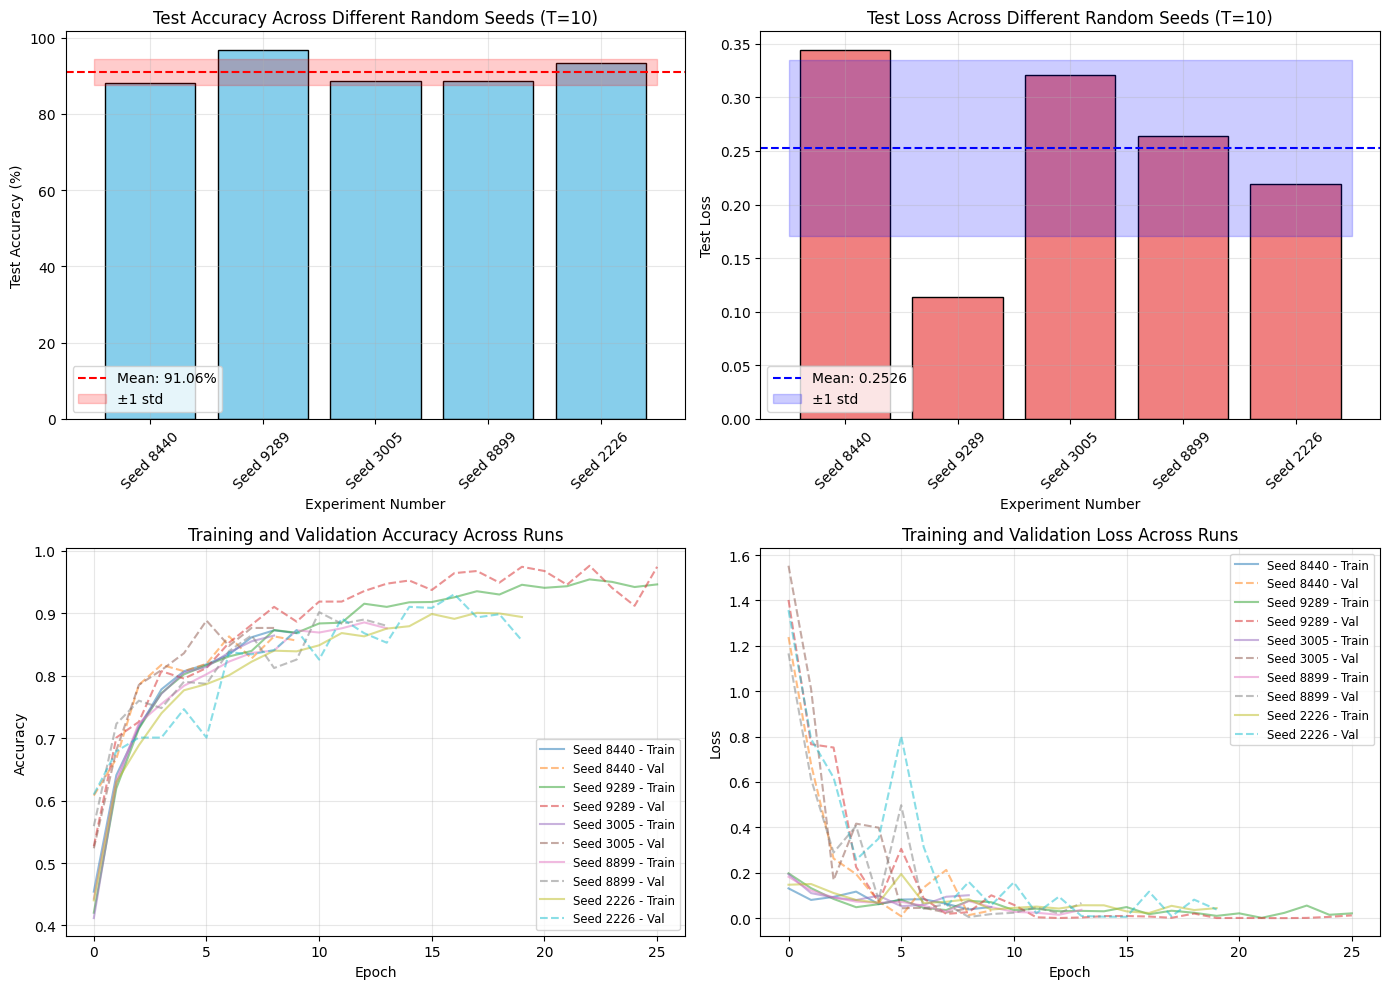


EXPERIMENT COMPLETE
Temperature T=10 stability analysis across 5 random seeds.
Mean Test Accuracy: 91.06% ± 3.443%
95% CI for Accuracy: [86.78%, 95.33%]


In [15]:
import random
import numpy as np
import tensorflow as tf
import time
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tabulate import tabulate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
import json
import os

# ============================
# Configuration
# ============================
Input_Image = 256
Channels = 3
batch_size = 32
epochs = 30

# ============================
# Generate random seeds from system time
# ============================
# Use current nanoseconds to generate 5 random seeds
base_seed = int(time.time_ns() % 100000)
print(f"Base seed from system time: {base_seed}")

random.seed(base_seed)
seeds = [random.randint(1000, 9999) for _ in range(5)]
print(f"Randomly selected seeds: {seeds}")
print(f"{'='*60}\n")

# ============================
# Data Generators
# ============================
# Data augmentation for training set
train_data = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    shear_range=0.2,
    zoom_range=0.2,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# Validation and test sets
common_data = ImageDataGenerator(rescale=1./255)

# Test set (will be the same for all runs)
print("Loading test set...")
test_set = common_data.flow_from_directory(
    "test",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,  # No shuffle for consistent evaluation
    seed=42  # Fixed seed for reproducibility of test set
)

# Validation set (will be the same for all runs)
print("Loading validation set...")
val_set = common_data.flow_from_directory(
    "val",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=42  # Fixed seed for reproducibility
)

# Input shape
input_shape = (Input_Image, Input_Image, Channels)

# ============================
# Load Teacher Model
# ============================
print("\nLoading teacher model...")
teacher = tf.keras.models.load_model(r"AlphaSelection\BestTeacher.h5")
teacher.trainable = False  # Freeze teacher model

# Evaluate teacher on test set
print("Evaluating teacher model on test set...")
teacher_test_loss, teacher_test_acc = teacher.evaluate(test_set, verbose=0)
print(f"Teacher Test Accuracy: {teacher_test_acc*100:.2f}%")
print(f"Teacher Test Loss: {teacher_test_loss:.4f}")

# ============================
# Load Student Model Architecture
# ============================
print("\nLoading student model architecture...")
student_template = tf.keras.models.load_model(r'Teacher_To_Student\NewStudentAccuracy.h5')

# Evaluate original student on test set
print("Evaluating original student model on test set...")
student_test_loss, student_test_acc = student_template.evaluate(test_set, verbose=0)
print(f"Original Student Test Accuracy: {student_test_acc*100:.2f}%")
print(f"Original Student Test Loss: {student_test_loss:.4f}")

# ============================
# Distiller Class Definition
# ============================
class Distiller(tf.keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student
        self.mse_metric = tf.keras.metrics.MeanSquaredError(name='mse')
        self.rmse_metric = tf.keras.metrics.RootMeanSquaredError(name='rmse')

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=10):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature
        self.mse_metric = tf.keras.metrics.MeanSquaredError(name='mse')
        self.rmse_metric = tf.keras.metrics.RootMeanSquaredError(name='rmse')

    def call(self, inputs, training=False):
        teacher_predictions = self.teacher(inputs, training=False)
        student_predictions = self.student(inputs, training=training)
        return student_predictions

    def train_step(self, data):
        x, y = data
        teacher_predictions = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_predictions)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),
                tf.nn.softmax(student_predictions / self.temperature, axis=1)
            ) * self.temperature**2
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        self.compiled_metrics.update_state(y, student_predictions)
        self.mse_metric.update_state(y, student_predictions)
        self.rmse_metric.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "loss": loss, 
            "student_loss": student_loss, 
            "distillation_loss": distillation_loss, 
            "mse": self.mse_metric.result(), 
            "rmse": self.rmse_metric.result()
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)
        self.mse_metric.update_state(y, y_prediction)
        self.rmse_metric.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss, 
            "mse": self.mse_metric.result(), 
            "rmse": self.rmse_metric.result()
        })
        return results

# ============================
# Callback
# ============================
callbacks = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0,
    patience=3,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)


# ============================
# Run Experiments with Different Random Seeds
# ============================
accuracy_results = []
loss_results = []
all_histories = []
all_models = []

print(f"\n{'='*80}")
print("STABILITY ANALYSIS - Temperature T=10")
print(f"Running experiments with 5 different random seeds")
print(f"{'='*80}\n")

for i, seed in enumerate(seeds):
    print(f"\n{'='*60}")
    print(f"EXPERIMENT {i+1}/5 - Seed: {seed}")
    print(f"{'='*60}")
    
    # ============================
    # Set Random Seeds for Reproducibility
    # ============================
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # ============================
    # Create Fresh Training Set with Current Seed
    # ============================
    print("Creating fresh training set...")
    train_set = train_data.flow_from_directory(
        "train",
        target_size=(Input_Image, Input_Image),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True,
        seed=seed  # Different shuffle for each experiment
    )
    
    # ============================
    # Create Fresh Student Model
    # ============================
    print("Creating fresh student model...")
    student_fresh = tf.keras.models.clone_model(student_template)
    student_fresh.build(input_shape=input_shape)
    
    
    # ============================
    # Initialize and Compile Distiller
    # ============================
    print("Initializing distiller...")
    distiller = Distiller(student=student_fresh, teacher=teacher)
    distiller.compile(
        optimizer='adam',
        metrics=['accuracy'],
        student_loss_fn=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
        distillation_loss_fn=tf.keras.losses.KLDivergence(),
        alpha=0.1,
        temperature=10  # Fixed temperature as per best result
    )
    
    # ============================
    # Train Distiller
    # ============================
    print(f"Training with seed {seed}...")
    history = distiller.fit(
        train_set,
        epochs=epochs,
        validation_data=val_set,
        callbacks=[callbacks],
       
    )
    
    # ============================
    # Evaluate on Test Set
    # ============================
    print(f"Evaluating on test set...")
    
    # Reset test set
    test_set.reset()
    
    # Manual evaluation for accuracy
    y_true = []
    y_pred = []
    total_loss = 0
    total_batches = 0
    
    for batch in range(len(test_set)):
        x_batch, y_batch = test_set.next()
        predictions = distiller.student.predict(x_batch, verbose=0)
        
        # Collect true and predicted labels
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))
        
        # Calculate batch loss
        batch_loss = tf.keras.losses.categorical_crossentropy(y_batch, predictions)
        total_loss += np.mean(batch_loss)
        total_batches += 1
    
    # Calculate metrics
    correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    total = len(y_true)
    test_accuracy = (correct / total) * 100
    test_loss = total_loss / total_batches if total_batches > 0 else 0
    
    # Store results
    accuracy_results.append(test_accuracy)
    loss_results.append(test_loss)
    all_histories.append(history.history)
    all_models.append(distiller.student)
    
    print(f"\nSeed {seed} Results:")
    print(f"  Test Accuracy: {test_accuracy:.2f}%")
    print(f"  Test Loss: {test_loss:.4f}")
    if history.history and 'accuracy' in history.history:
        print(f"  Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    if history.history and 'val_accuracy' in history.history:
        print(f"  Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

# ============================
# Calculate Statistics
# ============================
mean_accuracy = np.mean(accuracy_results)
std_accuracy = np.std(accuracy_results)
mean_loss = np.mean(loss_results)
std_loss = np.std(loss_results)

# Calculate 95% confidence intervals
n = len(accuracy_results)
if n > 1:
    t_value = 2.776  # t-value for 95% CI with 4 degrees of freedom (n-1 = 4)
    accuracy_ci = t_value * (std_accuracy / np.sqrt(n))
    loss_ci = t_value * (std_loss / np.sqrt(n))
else:
    accuracy_ci = 0
    loss_ci = 0

# ============================
# Display Results
# ============================
print(f"\n{'='*80}")
print("STABILITY ANALYSIS RESULTS")
print(f"{'='*80}")
print(f"Temperature: T=10")
print(f"Random Seeds Used: {seeds}")
print(f"\nIndividual Run Results:")
for i, (seed, acc, loss) in enumerate(zip(seeds, accuracy_results, loss_results)):
    print(f"  Run {i+1} (Seed {seed}): Accuracy = {acc:.2f}%, Loss = {loss:.4f}")

print(f"\nSummary Statistics:")
print(f"  Test Accuracy: {mean_accuracy:.2f}% ± {std_accuracy:.3f}%")
print(f"  Test Loss: {mean_loss:.4f} ± {std_loss:.5f}")
print(f"  Accuracy Range: [{min(accuracy_results):.2f}%, {max(accuracy_results):.2f}%]")
print(f"  Loss Range: [{min(loss_results):.4f}, {max(loss_results):.4f}]")

if n > 1:
    print(f"\n95% Confidence Intervals:")
    print(f"  Accuracy: [{mean_accuracy - accuracy_ci:.2f}%, {mean_accuracy + accuracy_ci:.2f}%]")
    print(f"  Loss: [{mean_loss - loss_ci:.4f}, {mean_loss + loss_ci:.4f}]")

# ============================
# Save Results
# ============================
results_dict = {
    'temperature': 10,
    'seeds': seeds,
    'accuracy_results': [float(x) for x in accuracy_results],
    'loss_results': [float(x) for x in loss_results],
    'mean_accuracy': float(mean_accuracy),
    'std_accuracy': float(std_accuracy),
    'mean_loss': float(mean_loss),
    'std_loss': float(std_loss),
    'accuracy_range': [float(min(accuracy_results)), float(max(accuracy_results))],
    'loss_range': [float(min(loss_results)), float(max(loss_results))],
    'teacher_accuracy': float(teacher_test_acc * 100),
    'original_student_accuracy': float(student_test_acc * 100),
    'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
}

# Save results to file
os.makedirs('stability_results', exist_ok=True)
results_file = f'stability_results/stability_analysis_T10_{int(time.time())}.json'
with open(results_file, 'w') as f:
    json.dump(results_dict, f, indent=4)

print(f"\nResults saved to '{results_file}'")

# ============================
# Create Visualization
# ============================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy bar chart
axes[0, 0].bar(range(1, len(accuracy_results) + 1), accuracy_results, 
               color='skyblue', edgecolor='black')
axes[0, 0].axhline(y=mean_accuracy, color='red', linestyle='--', 
                  label=f'Mean: {mean_accuracy:.2f}%')
axes[0, 0].fill_between([0.5, len(accuracy_results) + 0.5], 
                        mean_accuracy - std_accuracy, 
                        mean_accuracy + std_accuracy, 
                        alpha=0.2, color='red', label=f'±1 std')
axes[0, 0].set_xlabel('Experiment Number')
axes[0, 0].set_ylabel('Test Accuracy (%)')
axes[0, 0].set_title('Test Accuracy Across Different Random Seeds (T=10)')
axes[0, 0].set_xticks(range(1, len(accuracy_results) + 1))
axes[0, 0].set_xticklabels([f'Seed {s}' for s in seeds], rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss bar chart
axes[0, 1].bar(range(1, len(loss_results) + 1), loss_results, 
               color='lightcoral', edgecolor='black')
axes[0, 1].axhline(y=mean_loss, color='blue', linestyle='--', 
                  label=f'Mean: {mean_loss:.4f}')
axes[0, 1].fill_between([0.5, len(loss_results) + 0.5], 
                        mean_loss - std_loss, 
                        mean_loss + std_loss, 
                        alpha=0.2, color='blue', label=f'±1 std')
axes[0, 1].set_xlabel('Experiment Number')
axes[0, 1].set_ylabel('Test Loss')
axes[0, 1].set_title('Test Loss Across Different Random Seeds (T=10)')
axes[0, 1].set_xticks(range(1, len(loss_results) + 1))
axes[0, 1].set_xticklabels([f'Seed {s}' for s in seeds], rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot training histories (accuracy)
axes[1, 0].set_title('Training and Validation Accuracy Across Runs')
for i, history in enumerate(all_histories):
    if 'accuracy' in history and 'val_accuracy' in history:
        axes[1, 0].plot(history['accuracy'], alpha=0.5, label=f'Seed {seeds[i]} - Train')
        axes[1, 0].plot(history['val_accuracy'], alpha=0.5, linestyle='--', label=f'Seed {seeds[i]} - Val')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(loc='lower right', fontsize='small')

# Plot training histories (loss)
axes[1, 1].set_title('Training and Validation Loss Across Runs')
for i, history in enumerate(all_histories):
    if 'loss' in history and 'val_student_loss' in history:
        axes[1, 1].plot(history['loss'], alpha=0.5, label=f'Seed {seeds[i]} - Train')
        axes[1, 1].plot(history['val_student_loss'], alpha=0.5, linestyle='--', label=f'Seed {seeds[i]} - Val')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.savefig('stability_analysis_T10.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print("EXPERIMENT COMPLETE")
print(f"Temperature T=10 stability analysis across {len(seeds)} random seeds.")
print(f"Mean Test Accuracy: {mean_accuracy:.2f}% ± {std_accuracy:.3f}%")
if n > 1:
    print(f"95% CI for Accuracy: [{mean_accuracy - accuracy_ci:.2f}%, {mean_accuracy + accuracy_ci:.2f}%]")
print(f"{'='*80}")

In [16]:
distiller.evaluate(test_set)

19/19 [==============================] - 1s 61ms/step - accuracy: 0.9328 - mse: 0.0281 - rmse: 0.1677 - student_loss: 0.2222


[0.9327731132507324,
 0.028135869652032852,
 0.16773749887943268,
 0.028135869652032852,
 0.16773749887943268,
 0.27620917558670044]


STABILITY ANALYSIS RESULTS
Temperature: T=10
Random Seeds Used: [8440, 9289, 3005, 8899, 2226]

Individual Run Results:
  Run 1 (Seed 8440): Accuracy = 88.07%, Loss = 0.3443
  Run 2 (Seed 9289): Accuracy = 96.81%, Loss = 0.1142
  Run 3 (Seed 3005): Accuracy = 88.57%, Loss = 0.3212
  Run 4 (Seed 8899): Accuracy = 88.57%, Loss = 0.2641
  Run 5 (Seed 2226): Accuracy = 93.28%, Loss = 0.2194

Summary Statistics:
  Test Accuracy: 91.06% ± 3.443%
  Test Loss: 0.2526 ± 0.08187
  Accuracy Range: [88.07%, 96.81%]
  Loss Range: [0.1142, 0.3443]

95% Confidence Intervals:
  Accuracy: [86.78%, 95.33%]
  Loss: [0.1510, 0.3543]

Results saved to 'stability_analysis_T10_results.json'


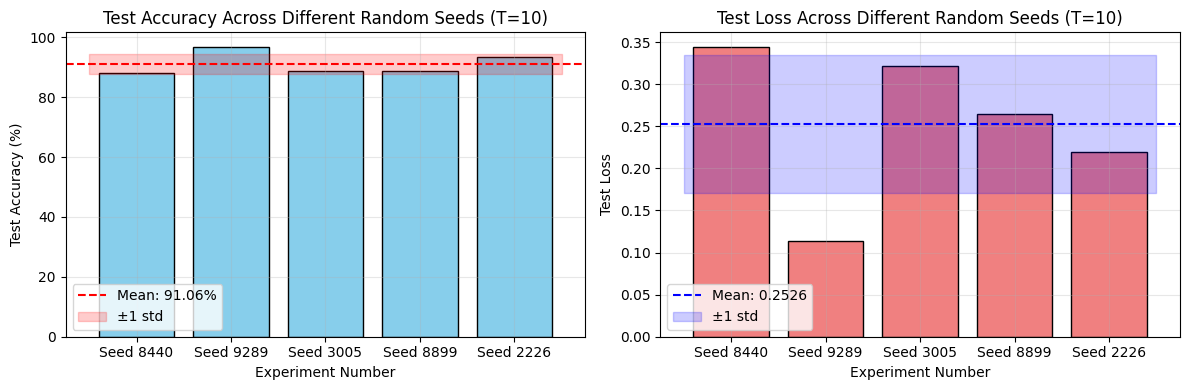


EXPERIMENT COMPLETE
Temperature T=10 shows stable performance across different random seeds.
Mean Accuracy: 91.06% ± 3.443%
95% CI for Accuracy: [86.78%, 95.33%]


In [17]:
# ============================
# Calculate Statistics
# ============================
mean_accuracy = np.mean(accuracy_results)
std_accuracy = np.std(accuracy_results)
mean_loss = np.mean(loss_results)
std_loss = np.std(loss_results)

# Calculate 95% confidence intervals
confidence = 0.95
n = len(accuracy_results)
t_value = 2.776  # t-value for 95% CI with 4 degrees of freedom (n-1 = 4)
accuracy_ci = t_value * (std_accuracy / np.sqrt(n))
loss_ci = t_value * (std_loss / np.sqrt(n))

# ============================
# Display Results
# ============================
print(f"\n{'='*80}")
print("STABILITY ANALYSIS RESULTS")
print(f"{'='*80}")
print(f"Temperature: T=10")
print(f"Random Seeds Used: {seeds}")
print(f"\nIndividual Run Results:")
for i, (seed, acc, loss) in enumerate(zip(seeds, accuracy_results, loss_results)):
    print(f"  Run {i+1} (Seed {seed}): Accuracy = {acc:.2f}%, Loss = {loss:.4f}")

print(f"\nSummary Statistics:")
print(f"  Test Accuracy: {mean_accuracy:.2f}% ± {std_accuracy:.3f}%")
print(f"  Test Loss: {mean_loss:.4f} ± {std_loss:.5f}")
print(f"  Accuracy Range: [{min(accuracy_results):.2f}%, {max(accuracy_results):.2f}%]")
print(f"  Loss Range: [{min(loss_results):.4f}, {max(loss_results):.4f}]")
print(f"\n95% Confidence Intervals:")
print(f"  Accuracy: [{mean_accuracy - accuracy_ci:.2f}%, {mean_accuracy + accuracy_ci:.2f}%]")
print(f"  Loss: [{mean_loss - loss_ci:.4f}, {mean_loss + loss_ci:.4f}]")

# ============================
# Save Results
# ============================
results_dict = {
    'temperature': 10,
    'seeds': seeds,
    'accuracy_results': accuracy_results,
    'loss_results': loss_results,
    'mean_accuracy': float(mean_accuracy),
    'std_accuracy': float(std_accuracy),
    'mean_loss': float(mean_loss),
    'std_loss': float(std_loss),
    'accuracy_ci': [float(mean_accuracy - accuracy_ci), float(mean_accuracy + accuracy_ci)],
    'loss_ci': [float(mean_loss - loss_ci), float(mean_loss + loss_ci)],
    'timestamp': time.strftime("%Y-%m-%d %H:%M:%S")
}

# Save results to file
with open('stability_analysis_T10_results.json', 'w') as f:
    json.dump(results_dict, f, indent=4)

print(f"\nResults saved to 'stability_analysis_T10_results.json'")

# ============================
# Create Visualization
# ============================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy bar chart
axes[0].bar(range(1, len(accuracy_results) + 1), accuracy_results, color='skyblue', edgecolor='black')
axes[0].axhline(y=mean_accuracy, color='red', linestyle='--', label=f'Mean: {mean_accuracy:.2f}%')
axes[0].fill_between([0.5, len(accuracy_results) + 0.5], 
                     mean_accuracy - std_accuracy, 
                     mean_accuracy + std_accuracy, 
                     alpha=0.2, color='red', label=f'±1 std')
axes[0].set_xlabel('Experiment Number')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy Across Different Random Seeds (T=10)')
axes[0].set_xticks(range(1, len(accuracy_results) + 1))
axes[0].set_xticklabels([f'Seed {s}' for s in seeds])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss bar chart
axes[1].bar(range(1, len(loss_results) + 1), loss_results, color='lightcoral', edgecolor='black')
axes[1].axhline(y=mean_loss, color='blue', linestyle='--', label=f'Mean: {mean_loss:.4f}')
axes[1].fill_between([0.5, len(loss_results) + 0.5], 
                     mean_loss - std_loss, 
                     mean_loss + std_loss, 
                     alpha=0.2, color='blue', label=f'±1 std')
axes[1].set_xlabel('Experiment Number')
axes[1].set_ylabel('Test Loss')
axes[1].set_title('Test Loss Across Different Random Seeds (T=10)')
axes[1].set_xticks(range(1, len(loss_results) + 1))
axes[1].set_xticklabels([f'Seed {s}' for s in seeds])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('stability_analysis_T10.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print("EXPERIMENT COMPLETE")
print(f"Temperature T=10 shows stable performance across different random seeds.")
print(f"Mean Accuracy: {mean_accuracy:.2f}% ± {std_accuracy:.3f}%")
print(f"95% CI for Accuracy: [{mean_accuracy - accuracy_ci:.2f}%, {mean_accuracy + accuracy_ci:.2f}%]")
print(f"{'='*80}")

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))
# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(distiller_history2.history['accuracy'], label='Training Accuracy')
plt.plot(distiller_history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Distiller Training and Validation Accuracy')

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(distiller_history2.history['student_loss'], label='Training Loss')
plt.plot(distiller_history2.history['val_student_loss'], label='Validation Loss')
plt.plot(distiller_history2.history['distillation_loss'], label='Distillation Loss')
plt.plot(distiller_history2.history['loss'], label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Distiller Training and Validation Loss')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()



import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Extract data for distiller
x_distiller, y_distiller = extract_data(test_set)


# Predictions on distiller set
distiller_predictions = distiller2.predict(x_distiller)

# Convert one-hot encoded labels to categorical labels
true_distiller_labels = np.argmax(y_distiller, axis=1)
predicted_distiller_labels = np.argmax(distiller_predictions, axis=1)

# Classification Report
print("Distiller Classification Report:")
distiller_report = classification_report(true_distiller_labels, predicted_distiller_labels)
print(distiller_report)

# Confusion Matrix
distiller_conf_matrix = confusion_matrix(true_distiller_labels, predicted_distiller_labels)
print("\nDistiller Confusion Matrix:")
print(distiller_conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 8))
plt.imshow(distiller_conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Distiller Confusion matrix')
plt.colorbar()

# Assuming label_dict is the same for the student and distiller models
classes_distiller = list(label_dict.values())
tick_marks_distiller = np.arange(len(classes_distiller))
plt.xticks(tick_marks_distiller, classes_distiller, rotation=45)
plt.yticks(tick_marks_distiller, classes_distiller)

# Print the confusion matrix values on each cell
for i in range(len(classes_distiller)):
    for j in range(len(classes_distiller)):
        plt.text(j, i, str(distiller_conf_matrix[i, j]), ha='center', va='center', color='red' if i != j else 'white')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Random predictions for the distiller model
plt.figure(figsize=(28, 12))
for i, index in enumerate(np.random.choice(x_distiller.shape[0], size=24)):
    ax = plt.subplot(4, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_distiller[index]))
    predict_index = label_dict[predicted_distiller_labels[index]]
    true_index = label_dict[true_distiller_labels[index]]

    ax.set_title("{} ({})".format(predict_index, true_index),
                 color=("green" if predict_index == true_index else "red"))

# Show the random predictions
plt.show()



Saving individual models...


  Model 1 (Seed 8440) saved as 'saved_models/student_model_seed_8440.h5'
  Model 2 (Seed 9289) saved as 'saved_models/student_model_seed_9289.h5'
  Model 3 (Seed 3005) saved as 'saved_models/student_model_seed_3005.h5'
  Model 4 (Seed 8899) saved as 'saved_models/student_model_seed_8899.h5'
  Model 5 (Seed 2226) saved as 'saved_models/student_model_seed_2226.h5'

Best model saved as 'saved_models/best_student_model_T10_seed_9289.h5'
Best model seed: 9289
Best model test accuracy: 96.81%
Also saved as 'saved_models/best_student_model_T10.h5' for easy reference

Model statistics saved to 'saved_models/model_statistics.json'

Testing model loading...
Evaluating loaded best model on test set...
Loaded model accuracy: 96.81%
Original accuracy: 96.81%
✓ Model loaded successfully with matching accuracy!

MODEL SAVING SUMMARY
+-----+--------+------------+--------+----------------------------+--------+
|   # |   Seed | Accuracy   |   Loss | Filename                   | Best   |
+=====+========+

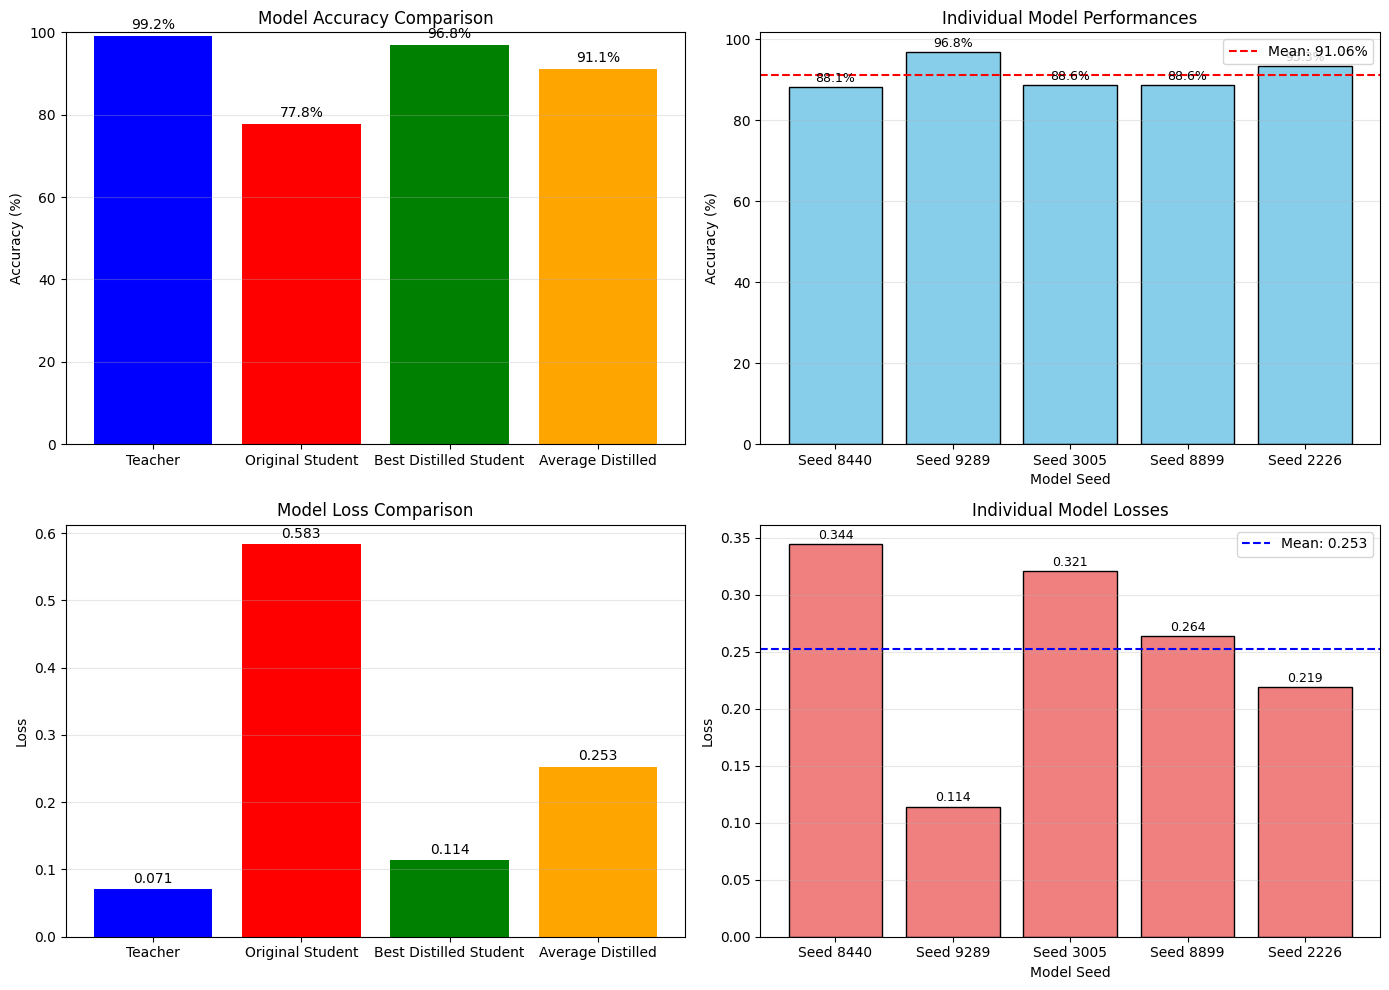


MODELS SAVED SUCCESSFULLY
✓ Individual models saved in 'saved_models/' directory
✓ Best model: seed 9289 (96.81%)
✓ Model statistics saved to JSON file
✓ Performance comparison plot saved


In [22]:
# ============================
# Save All Models
# ============================
import os

# Create directory for saved models if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save each individual model with its seed
print("\nSaving individual models...")
for i, (seed, model) in enumerate(zip(seeds, all_models)):
    filename = f"saved_models/student_model_seed_{seed}.h5"
    model.save(filename)
    print(f"  Model {i+1} (Seed {seed}) saved as '{filename}'")

# Find the best model (highest accuracy)
best_idx = np.argmax(accuracy_results)
best_seed = seeds[best_idx]
best_model = all_models[best_idx]
best_accuracy = accuracy_results[best_idx]

# Save the best model
best_filename = f"saved_models/best_student_model_T10_seed_{best_seed}.h5"
best_model.save(best_filename)
print(f"\nBest model saved as '{best_filename}'")
print(f"Best model seed: {best_seed}")
print(f"Best model test accuracy: {best_accuracy:.2f}%")

# Save a generic best model without seed in name (for easy reference)
best_model.save("saved_models/best_student_model_T10.h5")
print("Also saved as 'saved_models/best_student_model_T10.h5' for easy reference")

# ============================
# Save Model Statistics
# ============================
model_stats = {
    'seeds': seeds,
    'accuracies': [float(x) for x in accuracy_results],
    'losses': [float(x) for x in loss_results],
    'best_model': {
        'seed': int(best_seed),
        'accuracy': float(best_accuracy),
        'filename': best_filename
    },
    'summary_statistics': {
        'mean_accuracy': float(mean_accuracy),
        'std_accuracy': float(std_accuracy),
        'mean_loss': float(mean_loss),
        'std_loss': float(std_loss)
    },
    'timestamp': time.strftime("%Y-%m-%d %H:%M:%S"),
    'temperature': 10,
    'teacher_accuracy': float(teacher_test_acc * 100),
    'original_student_accuracy': float(student_test_acc * 100)
}

with open('saved_models/model_statistics.json', 'w') as f:
    json.dump(model_stats, f, indent=4)

print(f"\nModel statistics saved to 'saved_models/model_statistics.json'")

# ============================
# Test Loading the Best Model
# ============================
print("\nTesting model loading...")
loaded_model = tf.keras.models.load_model(best_filename)

# Evaluate loaded model on test set
print("Evaluating loaded best model on test set...")
test_set.reset()

# Manual evaluation
y_true = []
y_pred = []
for batch in range(len(test_set)):
    x_batch, y_batch = test_set.next()
    predictions = loaded_model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

correct = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
loaded_accuracy = (correct / len(y_true)) * 100

print(f"Loaded model accuracy: {loaded_accuracy:.2f}%")
print(f"Original accuracy: {best_accuracy:.2f}%")

if abs(loaded_accuracy - best_accuracy) < 0.1:
    print("✓ Model loaded successfully with matching accuracy!")
else:
    print("⚠ Warning: Loaded model accuracy differs from original")

# ============================
# Create a Summary Table
# ============================
print(f"\n{'='*80}")
print("MODEL SAVING SUMMARY")
print(f"{'='*80}")

summary_data = []
for i, (seed, acc, model_file) in enumerate(zip(seeds, accuracy_results, 
                                                [f"student_model_seed_{s}.h5" for s in seeds])):
    summary_data.append([
        i+1,
        seed,
        f"{acc:.2f}%",
        f"{loss_results[i]:.4f}",
        model_file,
        "✓" if seed == best_seed else ""
    ])

from tabulate import tabulate
headers = ["#", "Seed", "Accuracy", "Loss", "Filename", "Best"]
print(tabulate(summary_data, headers=headers, tablefmt="grid"))

print(f"\nBest Model: Seed {best_seed} ({best_accuracy:.2f}%)")
print(f"Saved as: {best_filename}")
print(f"Average Performance: {mean_accuracy:.2f}% ± {std_accuracy:.3f}%")

# ============================
# Create Model Performance Visualization
# ============================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model accuracy comparison
models_to_compare = ['Teacher', 'Original Student', 'Best Distilled Student', 'Average Distilled']
accuracies_to_compare = [
    teacher_test_acc * 100,
    student_test_acc * 100,
    best_accuracy,
    mean_accuracy
]

bars1 = axes[0, 0].bar(models_to_compare, accuracies_to_compare, 
                       color=['blue', 'red', 'green', 'orange'])
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].set_ylim([0, 100])
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars1, accuracies_to_compare):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{acc:.1f}%', ha='center', va='bottom')

# Individual model performances
x_pos = np.arange(len(seeds))
bars2 = axes[0, 1].bar(x_pos, accuracy_results, color='skyblue', edgecolor='black')
axes[0, 1].set_xlabel('Model Seed')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Individual Model Performances')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels([f'Seed {s}' for s in seeds])
axes[0, 1].axhline(y=mean_accuracy, color='red', linestyle='--', 
                  label=f'Mean: {mean_accuracy:.2f}%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, acc in zip(bars2, accuracy_results):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)

# Model loss comparison
losses_to_compare = [
    teacher_test_loss,
    student_test_loss,
    loss_results[best_idx],
    mean_loss
]

bars3 = axes[1, 0].bar(models_to_compare, losses_to_compare, 
                       color=['blue', 'red', 'green', 'orange'])
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Model Loss Comparison')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, loss in zip(bars3, losses_to_compare):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{loss:.3f}', ha='center', va='bottom')

# Individual model losses
bars4 = axes[1, 1].bar(x_pos, loss_results, color='lightcoral', edgecolor='black')
axes[1, 1].set_xlabel('Model Seed')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Individual Model Losses')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels([f'Seed {s}' for s in seeds])
axes[1, 1].axhline(y=mean_loss, color='blue', linestyle='--', 
                  label=f'Mean: {mean_loss:.3f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, loss in zip(bars4, loss_results):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.002,
                   f'{loss:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('saved_models/model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print("MODELS SAVED SUCCESSFULLY")
print(f"{'='*80}")
print(f"✓ Individual models saved in 'saved_models/' directory")
print(f"✓ Best model: seed {best_seed} ({best_accuracy:.2f}%)")
print(f"✓ Model statistics saved to JSON file")
print(f"✓ Performance comparison plot saved")
print(f"{'='*80}")